# 🧠 Penanganan Imbalanced Dataset pada Prediksi Stroke
**Kelompok 9**

---

Notebook ini membahas perbandingan tiga pendekatan penanganan **imbalanced class** untuk prediksi stroke:
- **Baseline** — tanpa resampling
- **SMOTE** — *Synthetic Minority Over-sampling Technique*
- **SMOTE-ENN** — kombinasi SMOTE + *Edited Nearest Neighbours*

Model klasifikasi yang digunakan: **Random Forest Classifier**

> 📁 Dataset berada di folder `data/healthcare-dataset-stroke-data.csv`

---
## 1. Import Library
Mengimpor semua library yang dibutuhkan untuk analisis data, visualisasi, pemodelan, dan penanganan imbalanced dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

import warnings
warnings.filterwarnings('ignore')

print('✅ Semua library berhasil diimpor!')

✅ Semua library berhasil diimpor!


---
## 2. Load Dataset
Dataset diambil dari folder `data/`. File `healthcare-dataset-stroke-data.csv` berisi data kesehatan ~5.110 pasien beserta label stroke.

In [2]:
# Path dataset relatif dari lokasi notebook
DATA_PATH = 'data/healthcare-dataset-stroke-data.csv'

df = pd.read_csv(DATA_PATH)

print(f'✅ Dataset berhasil dimuat!')
print(f'   Jumlah baris   : {df.shape[0]}')
print(f'   Jumlah kolom   : {df.shape[1]}')
df.head()

✅ Dataset berhasil dimuat!
   Jumlah baris   : 5110
   Jumlah kolom   : 12


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


---
## 3. Gambaran Umum Dataset
Melihat informasi tipe data tiap kolom dan statistik deskriptif untuk memahami karakteristik dataset secara keseluruhan.

In [3]:
print('=' * 50)
print('INFO DATASET')
print('=' * 50)
print(df.info())

print('\n' + '=' * 50)
print('STATISTIK DESKRIPTIF')
print('=' * 50)
df.describe()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

STATISTIK DESKRIPTIF


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


---
## 4. Distribusi Fitur
Memvisualisasikan distribusi untuk tiga jenis fitur:
- **Numerik**: `age`, `avg_glucose_level`, `bmi`
- **Kategorikal**: `gender`, `work_type`, `smoking_status`, `Residence_type`
- **Biner**: `hypertension`, `heart_disease`, `ever_married`

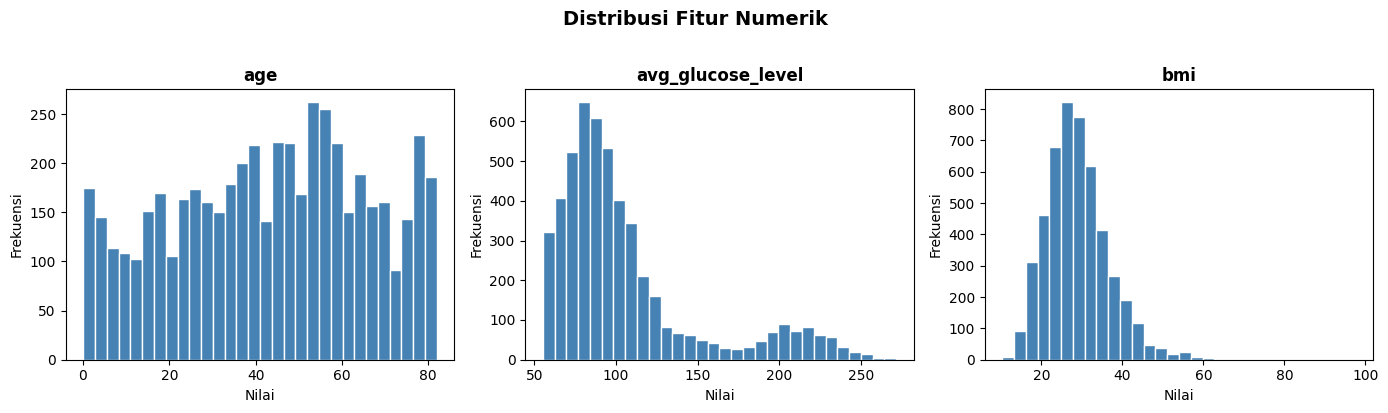

In [4]:
# --- Fitur Numerik ---
num_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

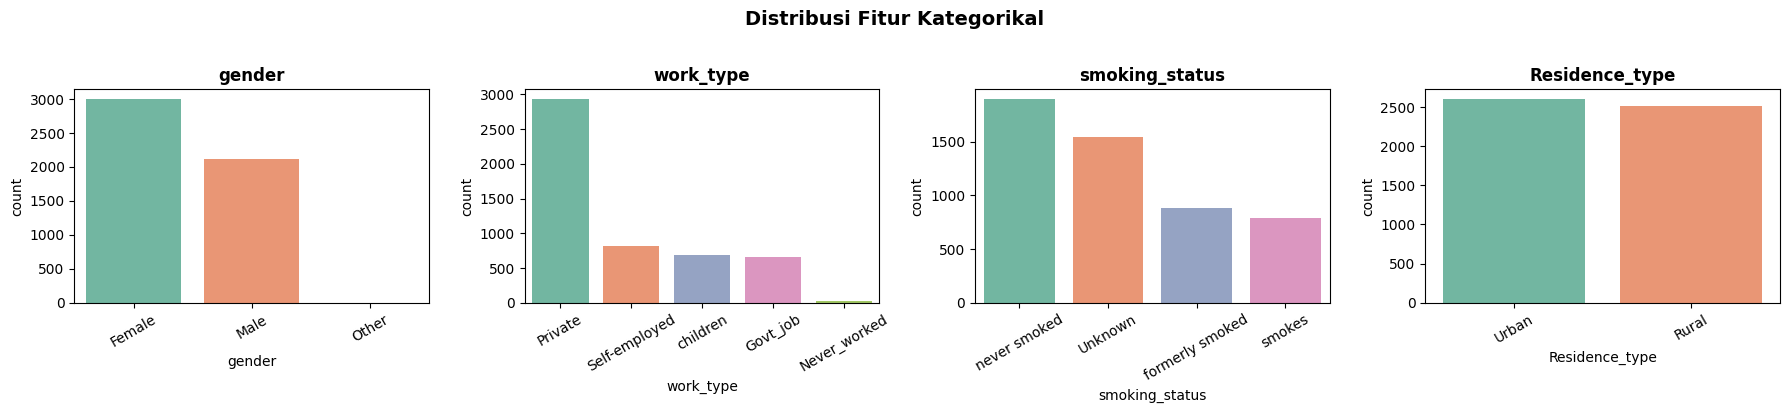

In [5]:
# --- Fitur Kategorikal ---
cat_cols = ['gender', 'work_type', 'smoking_status', 'Residence_type']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, palette='Set2', ax=ax)
    ax.set_title(col, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

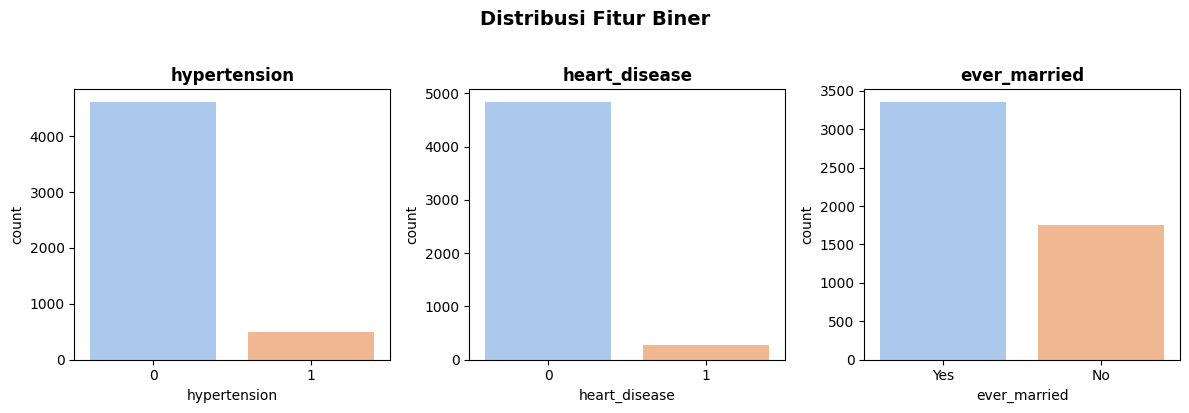

In [6]:
# --- Fitur Biner ---
bin_cols = ['hypertension', 'heart_disease', 'ever_married']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, bin_cols):
    sns.countplot(x=col, data=df, palette='pastel', ax=ax)
    ax.set_title(col, fontweight='bold')

plt.suptitle('Distribusi Fitur Biner', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Distribusi Target (Stroke)
Melihat seberapa parah ketidakseimbangan kelas pada variabel target `stroke`.

> ⚠️ Dataset medis seperti ini cenderung sangat **imbalanced** — jumlah pasien yang tidak stroke jauh lebih banyak daripada yang stroke.

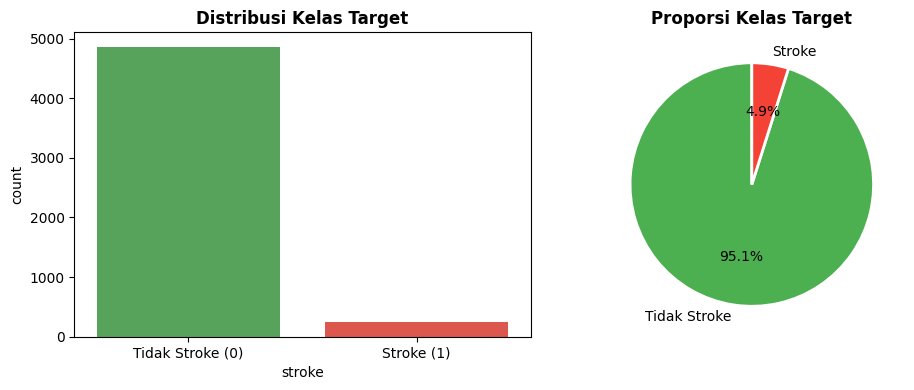

Distribusi kelas:
stroke
0    4861
1     249
Name: count, dtype: int64

Rasio imbalanced: 1 : 19


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
counts = df['stroke'].value_counts()
sns.countplot(x='stroke', data=df, palette=['#4CAF50', '#F44336'], ax=axes[0])
axes[0].set_title('Distribusi Kelas Target', fontweight='bold')
axes[0].set_xticklabels(['Tidak Stroke (0)', 'Stroke (1)'])

# Pie chart
axes[1].pie(counts, labels=['Tidak Stroke', 'Stroke'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Target', fontweight='bold')

plt.tight_layout()
plt.show()

print('Distribusi kelas:')
print(counts)
print(f'\nRasio imbalanced: 1 : {counts[0]//counts[1]}')

---
## 6. Penanganan Missing Value
Mengidentifikasi dan menangani nilai yang hilang. Kolom `bmi` diketahui memiliki beberapa nilai kosong (N/A), yang akan diisi dengan nilai rata-rata.

Missing value per kolom:
bmi    201
dtype: int64


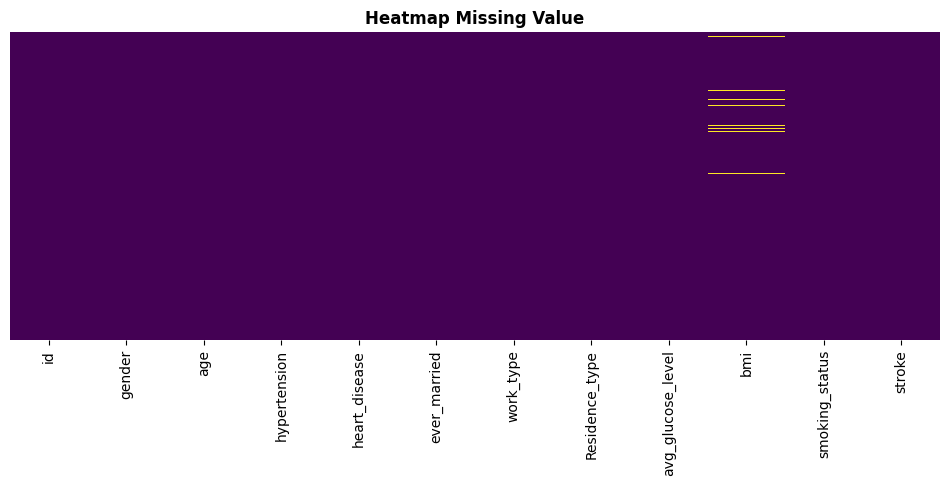


✅ Missing value setelah imputasi: 0


In [8]:
print('Missing value per kolom:')
missing = df.isnull().sum()
print(missing[missing > 0])

# Heatmap missing value
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap Missing Value', fontweight='bold')
plt.show()

# Imputasi BMI dengan mean
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')  # konversi 'N/A' string ke NaN
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

print(f'\n✅ Missing value setelah imputasi: {df.isnull().sum().sum()}')

---
## 7. Encoding & Preprocessing
Mengubah fitur kategorikal menjadi numerik menggunakan **Label Encoding**, lalu menghapus kolom `id` yang tidak diperlukan.

In [9]:
le = LabelEncoder()
cat_encode = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in cat_encode:
    df[col] = le.fit_transform(df[col])

df.drop('id', axis=1, inplace=True)

print('✅ Encoding selesai. Cuplikan data setelah encoding:')
df.head()

✅ Encoding selesai. Cuplikan data setelah encoding:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,0,61.0,0,0,1,3,0,202.21,28.893237,2,1
2,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,0,79.0,1,0,1,3,0,174.12,24.000000,2,1


---
## 8. Split Data & Normalisasi
Memisahkan fitur (X) dan target (y), melakukan normalisasi dengan **StandardScaler**, kemudian membagi data menjadi 80% train dan 20% test.

In [10]:
X = df.drop('stroke', axis=1)
y = df['stroke']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Ukuran data train : {len(X_train)} sampel')
print(f'Ukuran data test  : {len(X_test)} sampel')
print(f'\nDistribusi kelas di train:')
print(pd.Series(y_train).value_counts())

Ukuran data train : 4088 sampel
Ukuran data test  : 1022 sampel

Distribusi kelas di train:
stroke
0    3889
1     199
Name: count, dtype: int64


---
## 9. Definisi Metode Resampling & Fungsi Evaluasi
Mendefinisikan tiga metode yang akan dibandingkan serta fungsi evaluasi yang menghitung berbagai metrik performa model.

In [11]:
# Definisi metode resampling
methods = {
    'Baseline'  : None,
    'SMOTE'     : SMOTE(random_state=42),
    'SMOTE-ENN' : SMOTEENN(random_state=42)
}

# Fungsi evaluasi model
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    result = {
        'Metode'    : name,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score'  : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, y_prob)
    }

    cm = confusion_matrix(y_test, y_pred)
    return result, cm

print('✅ Metode dan fungsi evaluasi siap digunakan.')

✅ Metode dan fungsi evaluasi siap digunakan.


---
## 10. Training Model
Melatih **Random Forest Classifier** untuk setiap metode resampling. Hasil distribusi kelas setelah resampling juga ditampilkan untuk memverifikasi proses balancing.

In [12]:
all_results = []
all_cm = {}

for name, sampler in methods.items():
    print(f'⏳ Training: {name}...')

    if sampler is None:
        X_tr, y_tr = X_train, y_train
    else:
        X_tr, y_tr = sampler.fit_resample(X_train, y_train)

    dist = pd.Series(y_tr).value_counts().to_dict()
    print(f'   Distribusi kelas: Tidak Stroke={dist.get(0,0)}, Stroke={dist.get(1,0)}')

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_tr, y_tr)

    result, cm = evaluate_model(model, X_test, y_test, name)
    all_results.append(result)
    all_cm[name] = cm

    print(f'   ✅ Selesai!\n')

print('🎉 Semua model berhasil ditraining!')

⏳ Training: Baseline...
   Distribusi kelas: Tidak Stroke=3889, Stroke=199
   ✅ Selesai!

⏳ Training: SMOTE...
   Distribusi kelas: Tidak Stroke=3889, Stroke=3889
   ✅ Selesai!

⏳ Training: SMOTE-ENN...
   Distribusi kelas: Tidak Stroke=3116, Stroke=3719
   ✅ Selesai!

🎉 Semua model berhasil ditraining!


---
## 11. Tabel Perbandingan Performa
Menampilkan ringkasan metrik evaluasi dari ketiga metode dalam bentuk tabel yang mudah dibandingkan.

In [13]:
df_compare = pd.DataFrame(all_results)
df_compare = df_compare.set_index('Metode')

# Highlight nilai tertinggi per kolom
print('Tabel Perbandingan Performa Model:')
df_compare.style\
    .format('{:.4f}')\
    .highlight_max(color='lightgreen', axis=0)

Tabel Perbandingan Performa Model:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Metode,,,,,
Baseline,0.9491,0.0000,0.0000,0.0000,0.7913
SMOTE,0.9227,0.1778,0.1600,0.1684,0.7875
SMOTE-ENN,0.8620,0.1630,0.4400,0.2378,0.8056


---
## 12. Visualisasi Distribusi Kelas per Metode
Membandingkan distribusi kelas pada data training sebelum dan sesudah diterapkan teknik resampling.

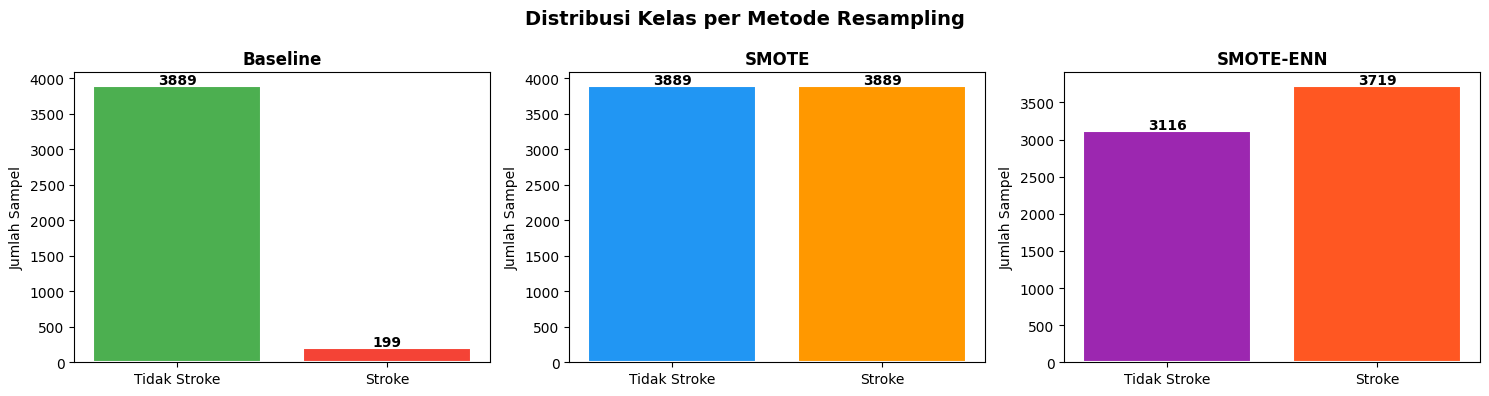

In [14]:
fig, axes = plt.subplots(1, len(methods), figsize=(15, 4))
colors = [['#4CAF50', '#F44336'], ['#2196F3', '#FF9800'], ['#9C27B0', '#FF5722']]

for i, (ax, (name, sampler)) in enumerate(zip(axes, methods.items())):
    if sampler is None:
        y_plot = y_train
    else:
        _, y_plot = sampler.fit_resample(X_train, y_train)

    counts = pd.Series(y_plot).value_counts().sort_index()
    bars = ax.bar(['Tidak Stroke', 'Stroke'], counts.values,
                  color=colors[i], edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(val), ha='center', fontweight='bold')

    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_ylabel('Jumlah Sampel')

plt.suptitle('Distribusi Kelas per Metode Resampling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Confusion Matrix
Menampilkan confusion matrix untuk setiap metode guna melihat detail prediksi benar dan salah per kelas.

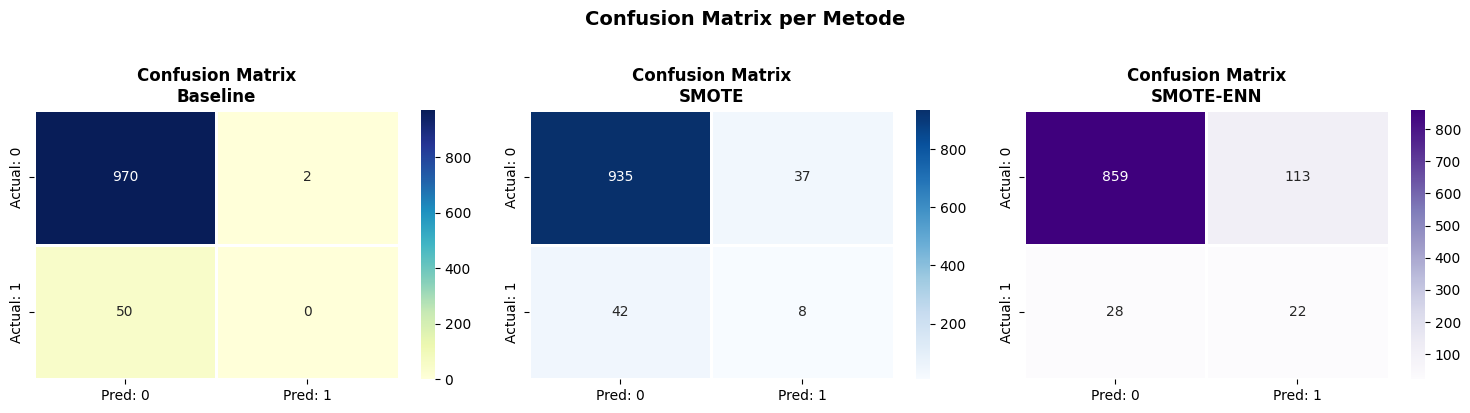

In [15]:
fig, axes = plt.subplots(1, len(all_cm), figsize=(15, 4))
cmaps = ['YlGnBu', 'Blues', 'Purples']

for i, (ax, (name, cm)) in enumerate(zip(axes, all_cm.items())):
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap=cmaps[i], linewidths=1, linecolor='white',
        xticklabels=['Pred: 0', 'Pred: 1'],
        yticklabels=['Actual: 0', 'Actual: 1'],
        ax=ax
    )
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold')

plt.suptitle('Confusion Matrix per Metode', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 14. Perbandingan Metrik Utama
Visualisasi perbandingan **F1-Score**, **Recall**, dan **ROC-AUC** — tiga metrik terpenting dalam kasus imbalanced classification.

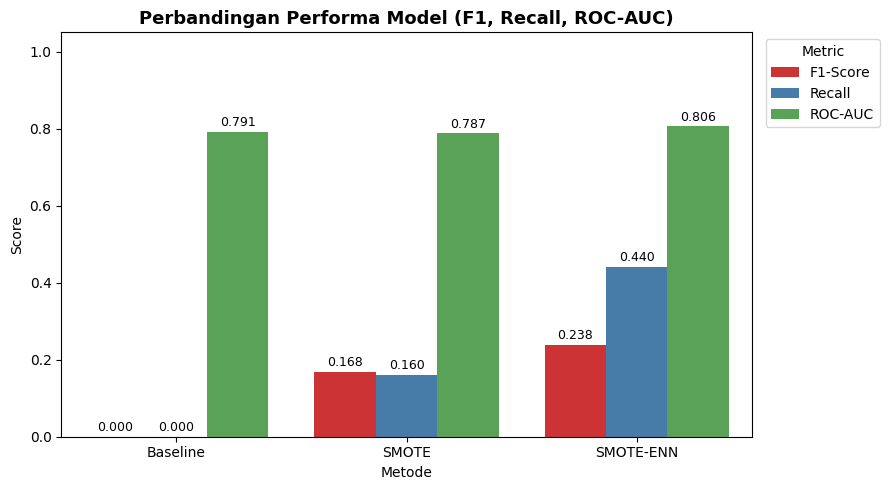

In [16]:
df_melt = df_compare.reset_index().melt(
    id_vars='Metode',
    value_vars=['F1-Score', 'Recall', 'ROC-AUC'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='Metode', y='Score', hue='Metric',
                 data=df_melt, palette='Set1')

# Label nilai di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=9)

plt.title('Perbandingan Performa Model (F1, Recall, ROC-AUC)',
          fontweight='bold', fontsize=13)
plt.ylabel('Score')
plt.xlabel('Metode')
plt.ylim(0, 1.05)
plt.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 15. Kesimpulan

Berdasarkan hasil eksperimen, berikut rangkuman perbandingan ketiga metode:

| Metode | Kelebihan | Kekurangan |
|---|---|---|
| **Baseline** | Akurasi tinggi (karena bias kelas mayoritas) | Recall kelas minoritas sangat rendah |
| **SMOTE** | Meningkatkan Recall & F1-Score | Bisa menghasilkan noise jika data overlap |
| **SMOTE-ENN** | Lebih bersih dari noise, Recall lebih baik | Training lebih lama, data lebih sedikit |

> 💡 **Untuk prediksi stroke**, metrik **Recall** dan **ROC-AUC** lebih penting dari Accuracy — karena *false negative* (melewatkan pasien stroke) jauh lebih berbahaya daripada *false positive*.